# Ensemble Methods — Bagging & Boosting
## California Housing Dataset

> **Dataset:** California Housing Prices  
> **Target:** `median_house_value`  
> **Models Covered:** Bagging · Random Forest · AdaBoost · Gradient Boosting · XGBoost

---

## Table of Contents
1. [Setup & Data Preparation](#1)
2. [Bagging Regressor](#2)
3. [Random Forest (Bagging++)](#3)
4. [AdaBoost](#4)
5. [Gradient Boosting](#5)
6. [XGBoost](#6)
7. [Hyperparameter Tuning — XGBoost](#7)
8. [Final Model Comparison](#8)
9. [Feature Importance Across Models](#9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('All libraries loaded')
print(f'XGBoost version: {xgb.__version__}')

All libraries loaded
XGBoost version: 3.2.0


---
<a id='1'></a>
## 1. Setup & Data Preparation

Same preprocessing pipeline as the regression notebook — fix missing values, engineer ratio features, encode categoricals, scale.

In [2]:
df = pd.read_csv('data/housing.csv')

# Fix missing values first
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Feature engineering
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']    / df['households']

# Encode categoricals
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Drop any inf/nan from ratio features
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

TARGET   = 'median_house_value'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features: {FEATURES}')

Train: (16346, 15)  |  Test: (4087, 15)
Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [3]:
# ── Shared evaluation & plotting helpers ────────────────────────────────────
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, use_scaled=True):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    tr_r2  = r2_score(y_tr, y_pred_tr)
    te_r2  = r2_score(y_te, y_pred_te)
    te_rmse = np.sqrt(mean_squared_error(y_te, y_pred_te))
    te_mae  = mean_absolute_error(y_te, y_pred_te)
    results[name] = {
        'Train R²': round(tr_r2,  4),
        'Test R²' : round(te_r2,  4),
        'RMSE ($)': round(te_rmse, 0),
        'MAE ($)' : round(te_mae,  0)
    }
    print(f'  Train R²  : {tr_r2:.4f}')
    print(f'  Test  R²  : {te_r2:.4f}')
    print(f'  RMSE      : ${te_rmse:,.0f}')
    print(f'  MAE       : ${te_mae:,.0f}')
    return y_pred_te


def plot_actual_vs_pred(y_true, y_pred, title, color='steelblue'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_true, y_pred, alpha=0.25, s=6, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    axes[0].set_xlabel('Actual ($)');  axes[0].set_ylabel('Predicted ($)')
    axes[0].set_title(f'{title} — Actual vs Predicted', fontweight='bold')
    axes[0].legend()
    resid = np.array(y_true) - y_pred
    axes[1].scatter(y_pred, resid, alpha=0.25, s=6, color='coral')
    axes[1].axhline(0, color='k', lw=1, ls='--')
    axes[1].set_xlabel('Predicted ($)');  axes[1].set_ylabel('Residual ($)')
    axes[1].set_title(f'{title} — Residuals', fontweight='bold')
    plt.tight_layout();  plt.show()

print('Helpers ready')

Helpers ready


---
<a id='2'></a>
## 2. Bagging Regressor

**Idea:** Train many independent copies of the same base learner on different **bootstrap samples** of the training data, then average their predictions.

```
Original Dataset
    ↓  bootstrap sampling (with replacement)
  [sample₁] [sample₂] ... [sampleₙ]
     ↓           ↓              ↓
  Model₁      Model₂  ...   Modelₙ
     ↓           ↓              ↓
         Average predictions
```

- Each model sees ~63% unique rows (37% left as Out-of-Bag)
- Models are trained **in parallel** — independent of each other
- Reduces **variance** without changing bias

In [4]:
print('=== Bagging Regressor (base: Decision Tree) ===')
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=8),
    n_estimators=100,
    max_samples=0.8,      # each tree sees 80% of data
    max_features=0.8,     # each tree sees 80% of features
    bootstrap=True,       # with replacement
    oob_score=True,       # free validation on unused samples
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train_s, y_train)
y_pred_bag = evaluate('Bagging', bagging, X_train_s, X_test_s, y_train, y_test)
print(f'  OOB (Out of bag) R²    : {bagging.oob_score_:.4f}  ← free estimate without test set')

=== Bagging Regressor (base: Decision Tree) ===
  Train R²  : 0.8209
  Test  R²  : 0.7787
  RMSE      : $55,007
  MAE       : $38,253
  OOB (Out of bag) R²    : 0.7792  ← free estimate without test set


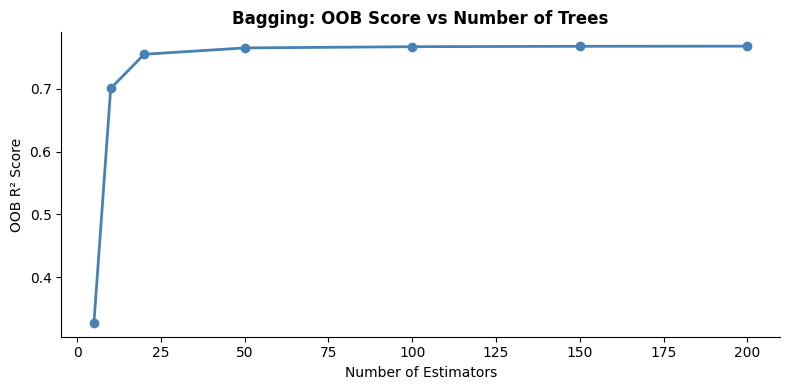

OOB score stabilises — adding more trees past a point gives diminishing returns


In [5]:
# Show how number of estimators affects OOB score
n_range = [5, 10, 20, 50, 100, 150, 200]
oob_scores = []
for n in n_range:
    m = BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=8),
        n_estimators=n, bootstrap=True, oob_score=True,
        random_state=42, n_jobs=-1
    ).fit(X_train_s, y_train)
    oob_scores.append(m.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_range, oob_scores, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Number of Estimators')
plt.ylabel('OOB R² Score')
plt.title('Bagging: OOB Score vs Number of Trees', fontweight='bold')
plt.tight_layout()
plt.show()
print('OOB score stabilises — adding more trees past a point gives diminishing returns')

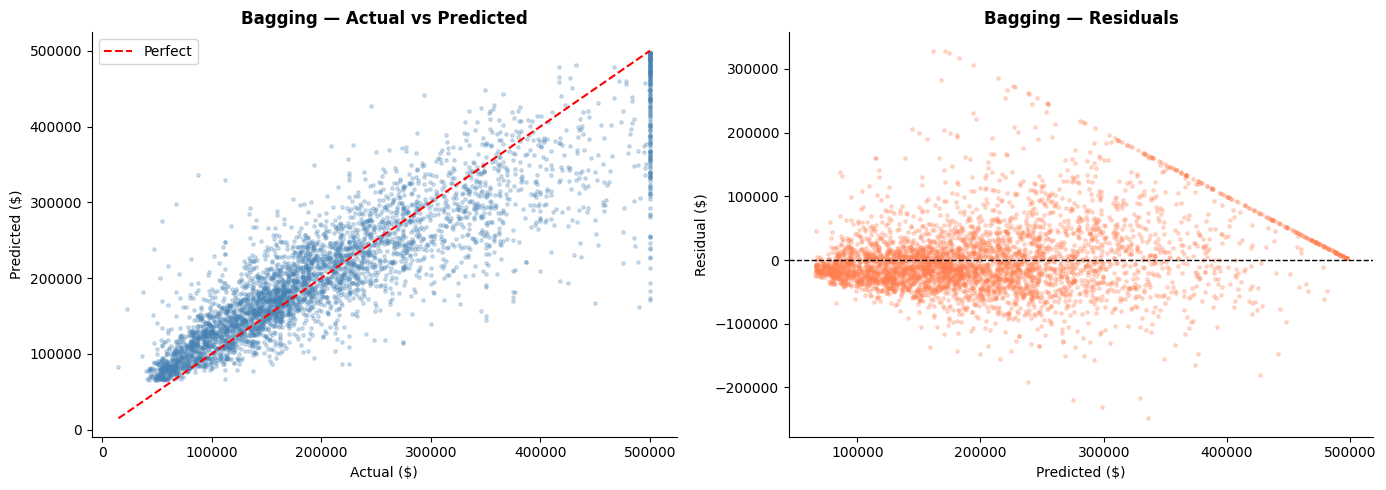

In [6]:
plot_actual_vs_pred(y_test, y_pred_bag, 'Bagging')

---
<a id='3'></a>
## 3. Random Forest (Bagging + Feature Randomness)

**Idea:** Bagging of Decision Trees **plus** random feature subsampling at every split — makes trees more diverse (less correlated), which further reduces variance.

```
Bagging:        bootstrap samples + all features at each split
Random Forest:  bootstrap samples + RANDOM SUBSET of features at each split
                                     ↑ extra diversity = lower tree correlation
```

In [7]:
print('=== Random Forest ===')
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,          # grow full trees
    max_features='sqrt',     # √p features per split
    min_samples_leaf=3,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = evaluate('Random Forest', rf, X_train_s, X_test_s, y_train, y_test)
print(f'  OOB R²    : {rf.oob_score_:.4f}')

=== Random Forest ===
  Train R²  : 0.9245
  Test  R²  : 0.8140
  RMSE      : $50,440
  MAE       : $33,799
  OOB R²    : 0.8105


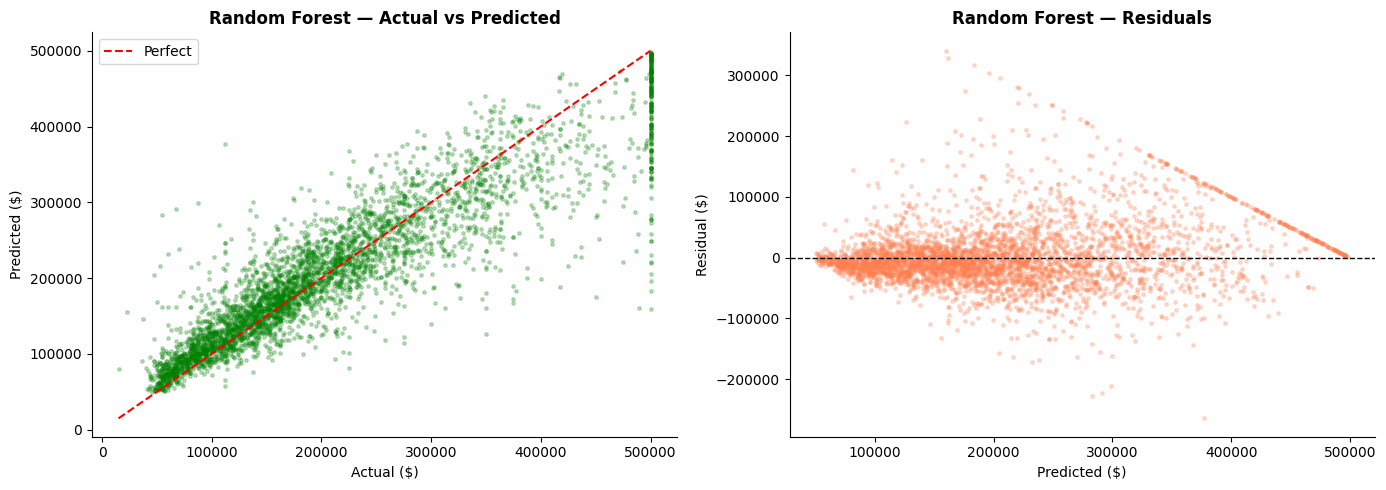

In [8]:
plot_actual_vs_pred(y_test, y_pred_rf, 'Random Forest', color='green')

---
<a id='4'></a>
## 4. AdaBoost (Adaptive Boosting)

**Idea:** Train weak learners **sequentially**. Each new learner focuses more on the samples that previous learners got wrong by increasing their weights.

```
Round 1:  Train weak model₁ on original data
          → misclassified samples get HIGHER weight

Round 2:  Train weak model₂ on re-weighted data
          → focuses on previously wrong samples

Round 3:  Train weak model₃ on re-weighted data
          → ...

Final:    Weighted vote:  ŷ = Σ αₜ · hₜ(x)
          better models get higher vote weight αₜ
```

- Default base learner: Decision Tree with `max_depth=1` (decision stump)
- Reduces **bias** — sequentially corrects errors
- Sensitive to **noisy data and outliers** (high weights on noisy samples)

In [9]:
print('=== AdaBoost Regressor ===')
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=200,
    learning_rate=0.1,   # shrinks contribution of each tree
    loss='linear',       # how weights are updated: linear / square / exponential
    random_state=42
)
ada.fit(X_train_s, y_train)
y_pred_ada = evaluate('AdaBoost', ada, X_train_s, X_test_s, y_train, y_test)

=== AdaBoost Regressor ===


  Train R²  : 0.6388
  Test  R²  : 0.6335
  RMSE      : $70,791
  MAE       : $57,957


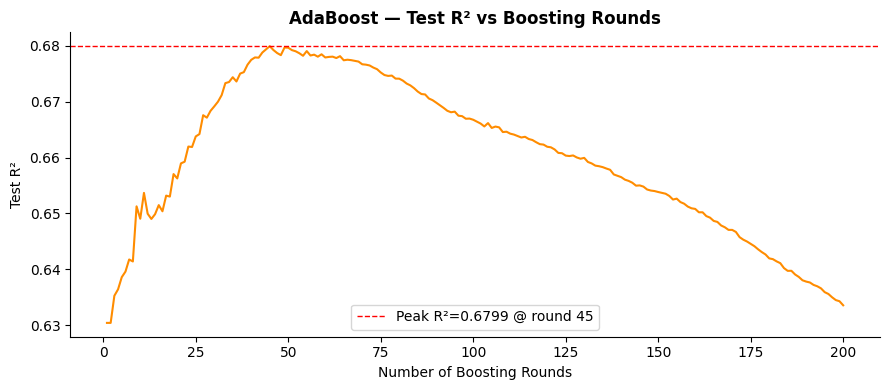

In [10]:
# AdaBoost: staged predictions — see how test error evolves with more trees
staged_r2 = [
    r2_score(y_test, pred)
    for pred in ada.staged_predict(X_test_s)
]

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(staged_r2)+1), staged_r2, color='darkorange', linewidth=1.5)
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Test R²')
plt.title('AdaBoost — Test R² vs Boosting Rounds', fontweight='bold')
plt.axhline(max(staged_r2), color='red', ls='--', lw=1, label=f'Peak R²={max(staged_r2):.4f} @ round {np.argmax(staged_r2)+1}')
plt.legend()
plt.tight_layout()
plt.show()

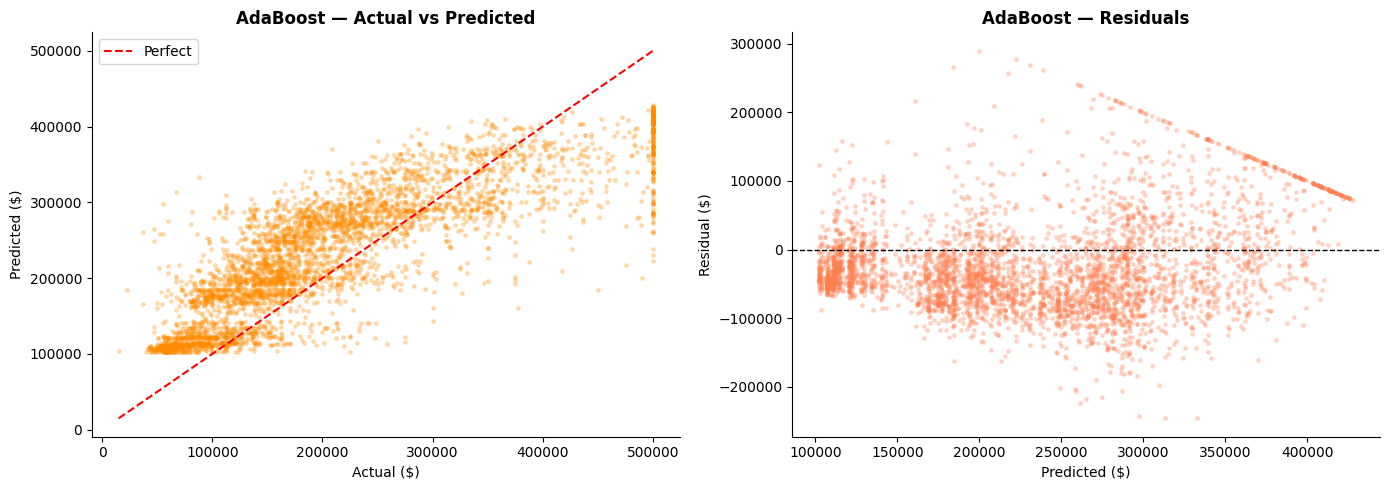

In [11]:
plot_actual_vs_pred(y_test, y_pred_ada, 'AdaBoost', color='darkorange')

---
<a id='5'></a>
## 5. Gradient Boosting

**Idea:** Each new tree is fit to the **residuals (errors)** of all previous trees. The model learns in the direction of steepest descent of the loss function.

```
Iteration 1:  ŷ₁ = initial prediction (e.g. mean of y)
              r₁ = y - ŷ₁             ← residuals

Iteration 2:  Fit tree₂ to r₁
              ŷ₂ = ŷ₁ + η·tree₂(x)   ← η = learning rate
              r₂ = y - ŷ₂

Iteration 3:  Fit tree₃ to r₂
              ŷ₃ = ŷ₂ + η·tree₃(x)
              ...

Final:        ŷ = Σ η·treeₜ(x)
```

- Slower but more powerful than AdaBoost
- `learning_rate` (η) vs `n_estimators` trade-off: small η needs more trees but generalises better
- **Does NOT parallelise** — trees must be built sequentially

In [12]:
print('=== Gradient Boosting Regressor ===')
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,    # small rate = better generalisation
    max_depth=4,
    subsample=0.8,         # stochastic GBM: each tree sees 80% of data
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_train_s, y_train)
y_pred_gb = evaluate('Gradient Boosting', gb, X_train_s, X_test_s, y_train, y_test)

=== Gradient Boosting Regressor ===
  Train R²  : 0.8605
  Test  R²  : 0.8239
  RMSE      : $49,068
  MAE       : $33,195


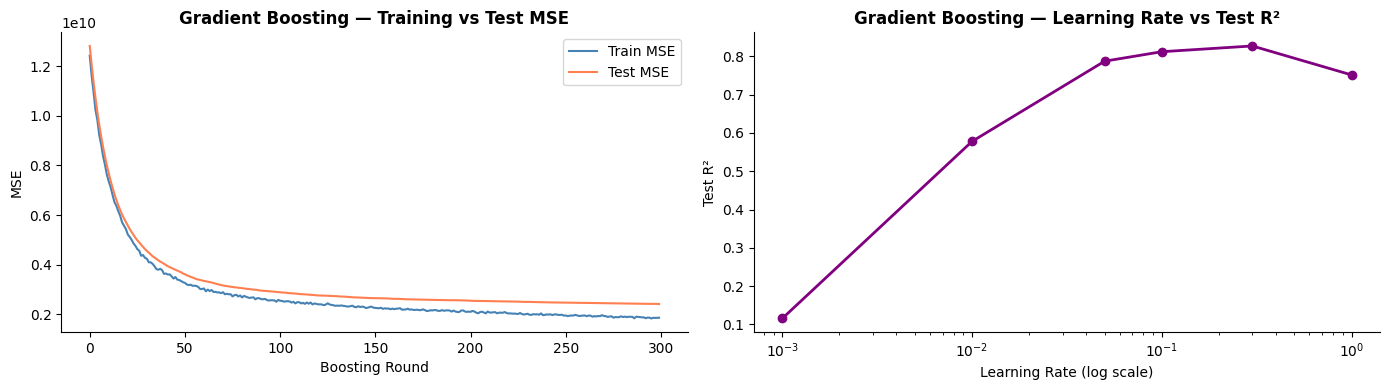

In [13]:
# Staged deviance — training and test loss per round
train_deviance = gb.train_score_
test_deviance  = [
    mean_squared_error(y_test, pred)
    for pred in gb.staged_predict(X_test_s)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_deviance, label='Train MSE', color='steelblue')
axes[0].plot(test_deviance,  label='Test MSE',  color='coral')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('MSE')
axes[0].set_title('Gradient Boosting — Training vs Test MSE', fontweight='bold')
axes[0].legend()

# Learning rate effect
lrs = [0.001, 0.01, 0.05, 0.1, 0.3, 1.0]
lr_test_r2 = []
for lr in lrs:
    m = GradientBoostingRegressor(n_estimators=100, learning_rate=lr,
                                   max_depth=4, random_state=42)
    m.fit(X_train_s, y_train)
    lr_test_r2.append(r2_score(y_test, m.predict(X_test_s)))

axes[1].semilogx(lrs, lr_test_r2, 'o-', color='purple', linewidth=2)
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Gradient Boosting — Learning Rate vs Test R²', fontweight='bold')

plt.tight_layout()
plt.show()

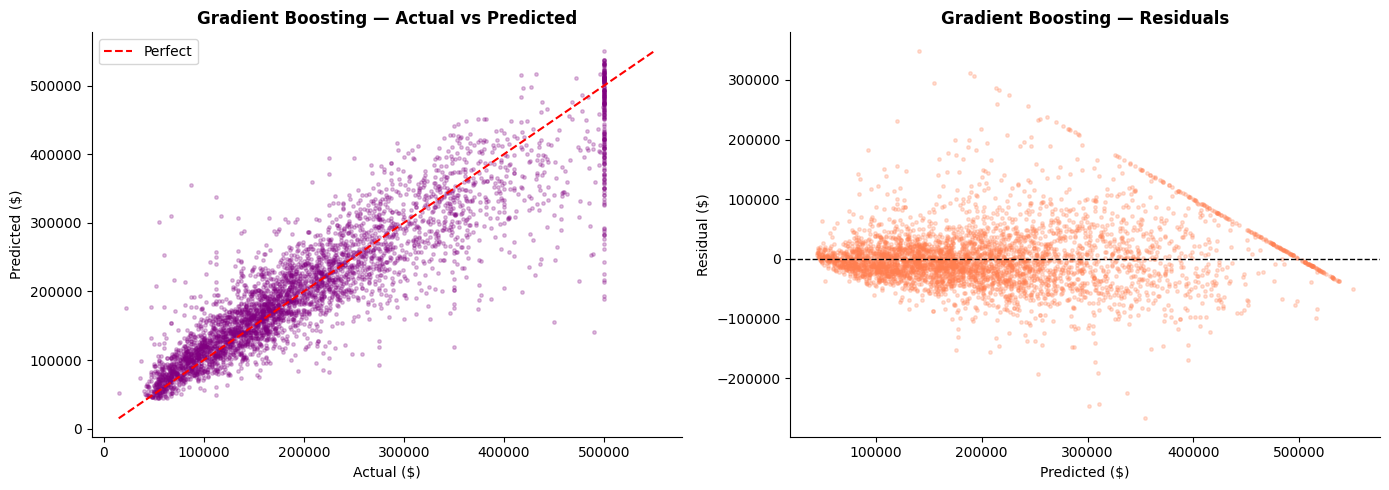

In [14]:
plot_actual_vs_pred(y_test, y_pred_gb, 'Gradient Boosting', color='purple')

---
<a id='6'></a>
## 6. XGBoost (Extreme Gradient Boosting)

**Idea:** Optimised, regularised version of Gradient Boosting that adds:
- **L1 + L2 regularisation** on leaf weights (prevents overfitting)
- **Second-order gradients** (Newton method) for faster, more accurate updates
- **Column subsampling** like Random Forest (feature randomness)
- **Parallel tree construction** within each level
- **Handling of missing values natively**

```
Gradient Boosting objective:
  Minimize:  Σ L(yᵢ, ŷᵢ)  (loss)

XGBoost objective:
  Minimize:  Σ L(yᵢ, ŷᵢ) + Σ Ω(fₜ)
                              ↑
                 regularisation term on tree complexity
                 Ω(f) = γ·T + ½λ·Σwⱼ²  (T=leaves, w=leaf weights)
```

In [15]:
print('=== XGBoost Regressor ===')
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,           # row subsampling
    colsample_bytree=0.8,    # column (feature) subsampling per tree
    colsample_bylevel=0.8,   # column subsampling per level
    reg_alpha=0.1,           # L1 regularisation on leaf weights
    reg_lambda=1.0,          # L2 regularisation on leaf weights
    min_child_weight=5,
    gamma=0.1,               # min loss reduction to make a split
    random_state=42,
    n_jobs=-1,
    tree_method='hist'       # fast histogram-based tree building
)

# Use early stopping to find best n_estimators automatically
xgb_model.fit(
    X_train_s, y_train,
    eval_set=[(X_train_s, y_train), (X_test_s, y_test)],
    verbose=False
)

y_pred_xgb = evaluate('XGBoost', xgb_model, X_train_s, X_test_s, y_train, y_test)

=== XGBoost Regressor ===
  Train R²  : 0.9074
  Test  R²  : 0.8424
  RMSE      : $46,431
  MAE       : $30,833


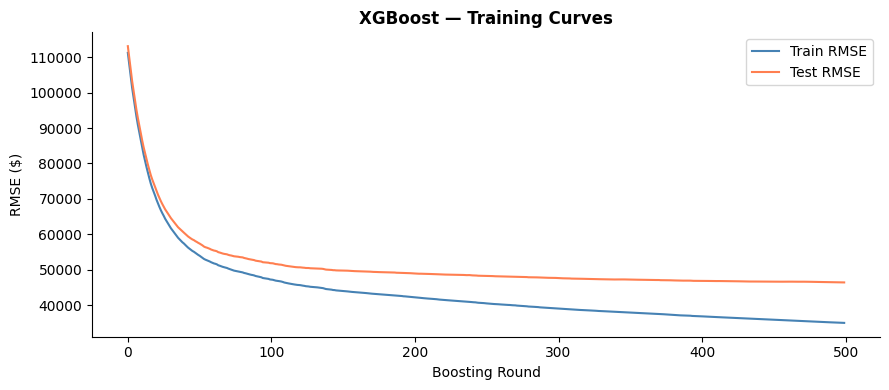

In [16]:
# XGBoost training curves from eval results
evals = xgb_model.evals_result()
train_rmse = evals['validation_0']['rmse']
test_rmse  = evals['validation_1']['rmse']

plt.figure(figsize=(9, 4))
plt.plot(train_rmse, label='Train RMSE', color='steelblue')
plt.plot(test_rmse,  label='Test RMSE',  color='coral')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE ($)')
plt.title('XGBoost — Training Curves', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

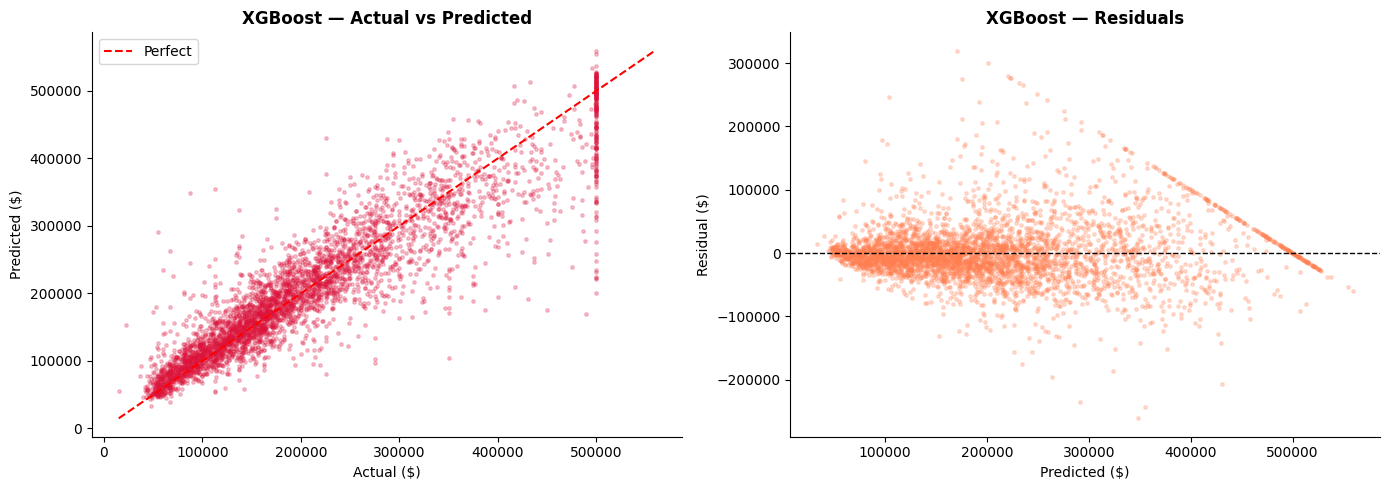

In [17]:
plot_actual_vs_pred(y_test, y_pred_xgb, 'XGBoost', color='crimson')

---
<a id='7'></a>
## 7. Hyperparameter Tuning — XGBoost (GridSearchCV)

Key XGBoost parameters to tune:

| Parameter | Controls | Effect of increasing |
|-----------|----------|---------------------|
| `n_estimators` | Number of trees | More complex model |
| `learning_rate` | Step size per tree | Smaller = more trees needed |
| `max_depth` | Max tree depth | More complex trees, risk overfit |
| `subsample` | Row fraction per tree | Lower = more regularisation |
| `colsample_bytree` | Feature fraction per tree | Lower = more regularisation |
| `reg_alpha` | L1 penalty | Sparse leaf weights |
| `reg_lambda` | L2 penalty | Smaller leaf weights |

In [ ]:
param_grid_xgb = {
    'max_depth'      : [3, 5, 7],
    'learning_rate'  : [0.05, 0.1],
    'subsample'      : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

param_grid_rf = {
    'n_estimators'   : [100, 200],
    'max_depth'      : [None, 10],
    'max_features'   : ['sqrt', 0.8],
    'min_samples_leaf': [1, 3]
}

xgb_base = xgb.XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

rf_base = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

search_obj = {
    'XGBoost': (xgb_base, param_grid_xgb),
    'Random Forest': (rf_base, param_grid_rf)
}

for name, (model, param_grid) in search_obj.items():
    print(f'\n=== Grid Search CV for {name} ===')

    gs = GridSearchCV(
        model, param_grid,
        cv=3, scoring='r2',
        n_jobs=-1, verbose=1
    )
    gs.fit(X_train_s, y_train)

    print(f'\nBest params : {gs.best_params_}')
    print(f'Best CV R²  : {gs.best_score_:.4f}')


=== Grid Search CV for XGBoost ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== Grid Search CV for Random Forest ===
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best params : {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²  : 0.8090


In [ ]:
# RandomCV can be used for larger grids to sample random combinations instead of exhaustive search
from sklearn.model_selection import RandomizedSearchCV


param_grid_xgb = {
    'max_depth'      : [3, 5, 7],
    'learning_rate'  : [0.05, 0.1],
    'subsample'      : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

param_grid_rf = {
    'n_estimators'   : [100, 200],
    'max_depth'      : [None, 10],
    'max_features'   : ['sqrt', 0.8],
    'min_samples_leaf': [1, 3]
}

xgb_base = xgb.XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

rf_base = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

search_obj = {
    'XGBoost': (xgb_base, param_grid_xgb),
    'Random Forest': (rf_base, param_grid_rf)
}

for name, (model, param_grid) in search_obj.items():
    print(f'\n=== Grid Search CV for {name} ===')

    gs = RandomizedSearchCV(
        model, param_grid,
        cv=3, scoring='r2',
        n_jobs=-1, verbose=1
    )
    gs.fit(X_train_s, y_train)

    print(f'\nBest params : {gs.best_params_}')
    print(f'Best CV R²  : {gs.best_score_:.4f}')


In [19]:
print('=== XGBoost (Tuned) ===')
xgb_tuned = xgb.XGBRegressor(
    **gs.best_params_,
    n_estimators=300,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)
xgb_tuned.fit(X_train_s, y_train)
y_pred_xgb_tuned = evaluate('XGBoost (Tuned)', xgb_tuned, X_train_s, X_test_s, y_train, y_test)

=== XGBoost (Tuned) ===


TypeError: xgboost.sklearn.XGBRegressor() got multiple values for keyword argument 'n_estimators'

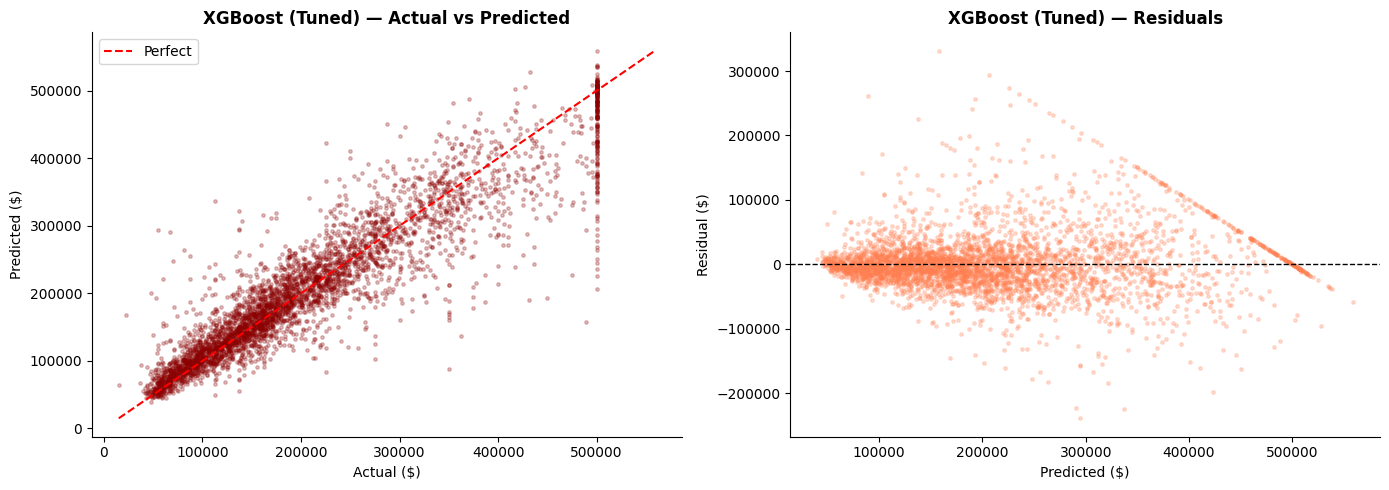

In [ ]:
plot_actual_vs_pred(y_test, y_pred_xgb_tuned, 'XGBoost (Tuned)', color='darkred')

---
<a id='8'></a>
## 8. Final Model Comparison

In [ ]:
res_df = pd.DataFrame(results).T.sort_values('Test R²', ascending=False)
print('='*65)
print('                    FINAL RESULTS')
print('='*65)
print(f'{"Model":<25} {"Train R²":>9} {"Test R²":>9} {"RMSE ($)":>12} {"MAE ($)":>10}')
print('-'*65)
for model, row in res_df.iterrows():
    gap = row['Train R²'] - row['Test R²']
    flag = ' ⚠ overfit' if gap > 0.05 else ''
    print(f'{model:<25} {row["Train R²"]:>9.4f} {row["Test R²"]:>9.4f} {row["RMSE ($)"]:>12,.0f} {row["MAE ($)"]:>10,.0f}{flag}')
print('='*65)
best = res_df['Test R²'].idxmax()
print(f'\nBest model : {best}')
print(f'Test R²    : {res_df.loc[best, "Test R²"]:.4f}')
print(f'RMSE       : ${res_df.loc[best, "RMSE ($)"]:,.0f}')

                    FINAL RESULTS
Model                      Train R²   Test R²     RMSE ($)    MAE ($)
-----------------------------------------------------------------
XGBoost (Tuned)              0.9722    0.8503       45,247     29,443 ⚠ overfit
XGBoost                      0.9074    0.8424       46,431     30,833 ⚠ overfit
Gradient Boosting            0.8605    0.8239       49,068     33,195
Random Forest                0.9245    0.8140       50,440     33,799 ⚠ overfit
Bagging                      0.8209    0.7787       55,007     38,253
AdaBoost                     0.6388    0.6335       70,791     57,957

Best model : XGBoost (Tuned)
Test R²    : 0.8503
RMSE       : $45,247


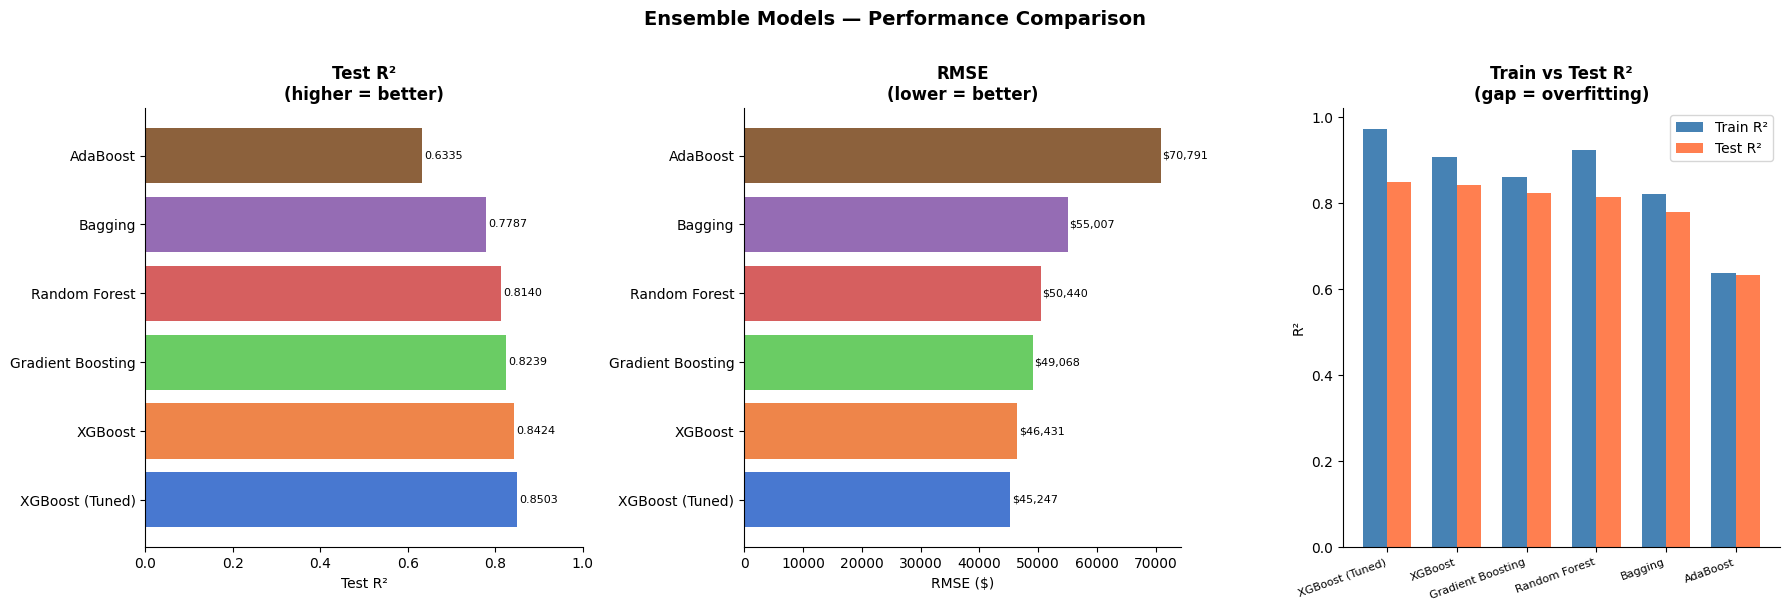

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = sns.color_palette('muted', len(res_df))
models  = res_df.index.tolist()

# Test R²
bars = axes[0].barh(models, res_df['Test R²'], color=palette)
axes[0].set_xlabel('Test R²')
axes[0].set_title('Test R²\n(higher = better)', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, res_df['Test R²']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# RMSE
bars2 = axes[1].barh(models, res_df['RMSE ($)'], color=palette)
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('RMSE\n(lower = better)', fontweight='bold')
for bar, val in zip(bars2, res_df['RMSE ($)']):
    axes[1].text(val + 300, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=8)

# Train vs Test R² gap (overfitting check)
x = np.arange(len(models))
w = 0.35
axes[2].bar(x - w/2, res_df['Train R²'], w, label='Train R²', color='steelblue')
axes[2].bar(x + w/2, res_df['Test R²'],  w, label='Test R²',  color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=20, ha='right', fontsize=8)
axes[2].set_ylabel('R²')
axes[2].set_title('Train vs Test R²\n(gap = overfitting)', fontweight='bold')
axes[2].legend()

plt.suptitle('Ensemble Models — Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

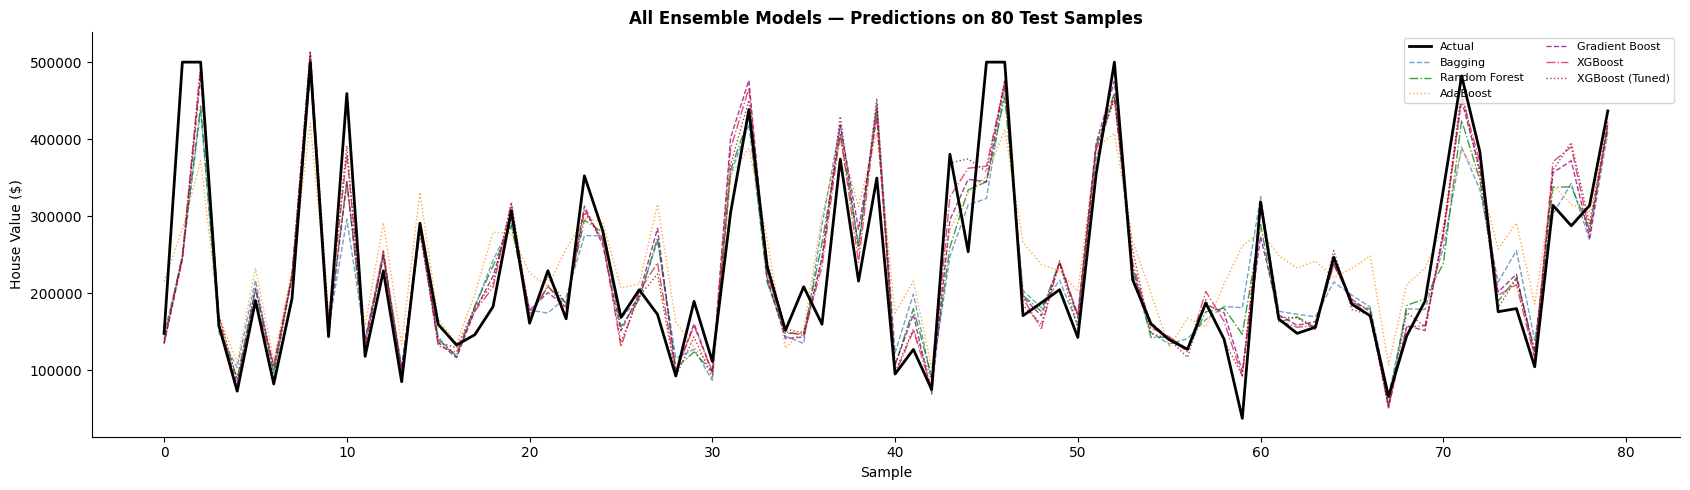

In [ ]:
# All-model predictions on 80 test samples
n = 80
idx = np.random.RandomState(1).choice(len(y_test), n, replace=False)

all_preds = {
    'Actual'          : y_test.values[idx],
    'Bagging'         : y_pred_bag[idx],
    'Random Forest'   : y_pred_rf[idx],
    'AdaBoost'        : y_pred_ada[idx],
    'Gradient Boost'  : y_pred_gb[idx],
    'XGBoost'         : y_pred_xgb[idx],
    'XGBoost (Tuned)' : y_pred_xgb_tuned[idx],
}

colors_map = {
    'Bagging'        : ('steelblue',  '--'),
    'Random Forest'  : ('green',      '-.'),
    'AdaBoost'       : ('darkorange', ':'),
    'Gradient Boost' : ('purple',     '--'),
    'XGBoost'        : ('crimson',    '-.'),
    'XGBoost (Tuned)': ('darkred',    ':'),
}

plt.figure(figsize=(17, 5))
xax = np.arange(n)
plt.plot(xax, all_preds['Actual'], 'k-', lw=2, label='Actual', zorder=10)
for name, (col, ls) in colors_map.items():
    plt.plot(xax, all_preds[name], ls, lw=1, color=col, alpha=0.75, label=name)
plt.xlabel('Sample')
plt.ylabel('House Value ($)')
plt.title(f'All Ensemble Models — Predictions on {n} Test Samples', fontweight='bold')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
<a id='9'></a>
## 9. Feature Importance Across Models

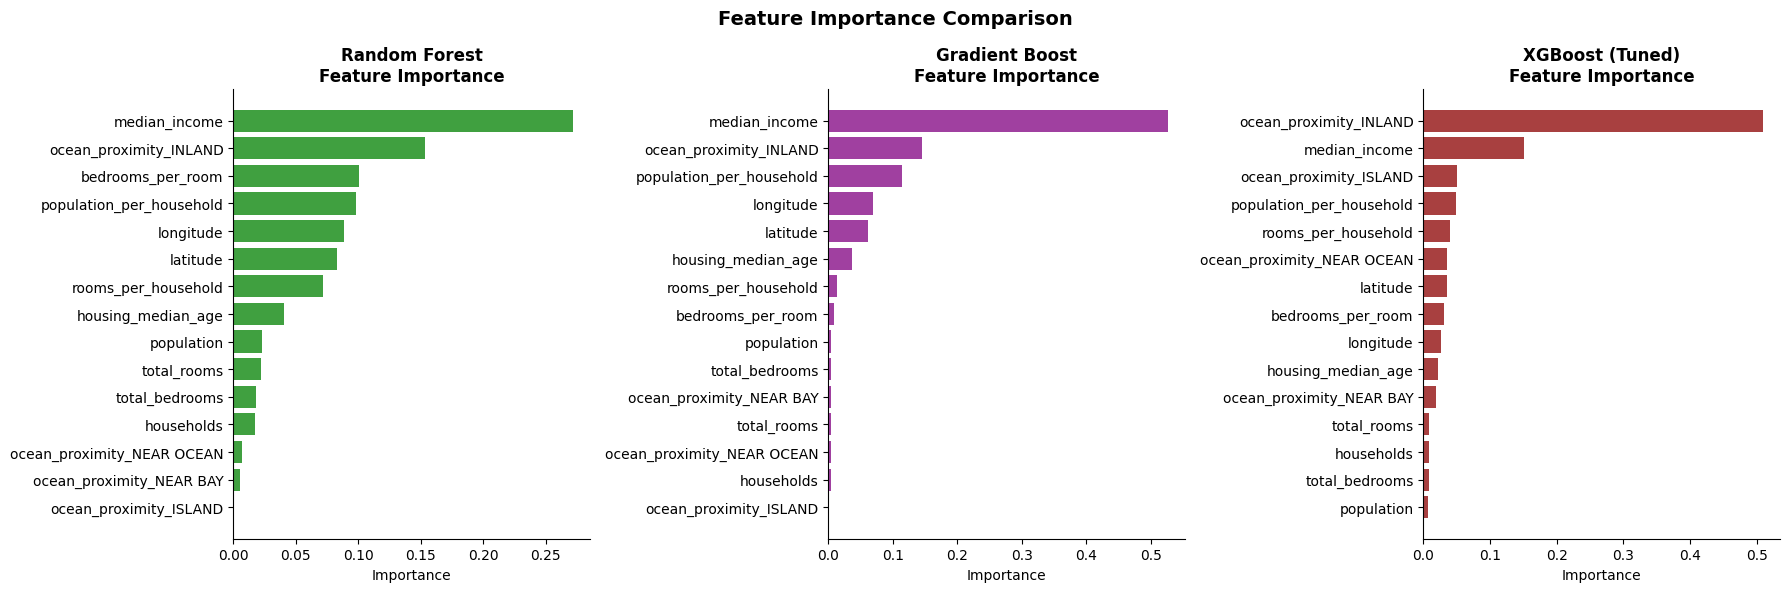

In [ ]:
importances = {
    'Random Forest'  : rf.feature_importances_,
    'Gradient Boost' : gb.feature_importances_,
    'XGBoost (Tuned)': xgb_tuned.feature_importances_,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_fi = ['green', 'purple', 'darkred']

for ax, (name, imp), col in zip(axes, importances.items(), colors_fi):
    fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': imp})
    fi_df = fi_df.sort_values('Importance', ascending=True)
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=col, alpha=0.75)
    ax.set_title(f'{name}\nFeature Importance', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

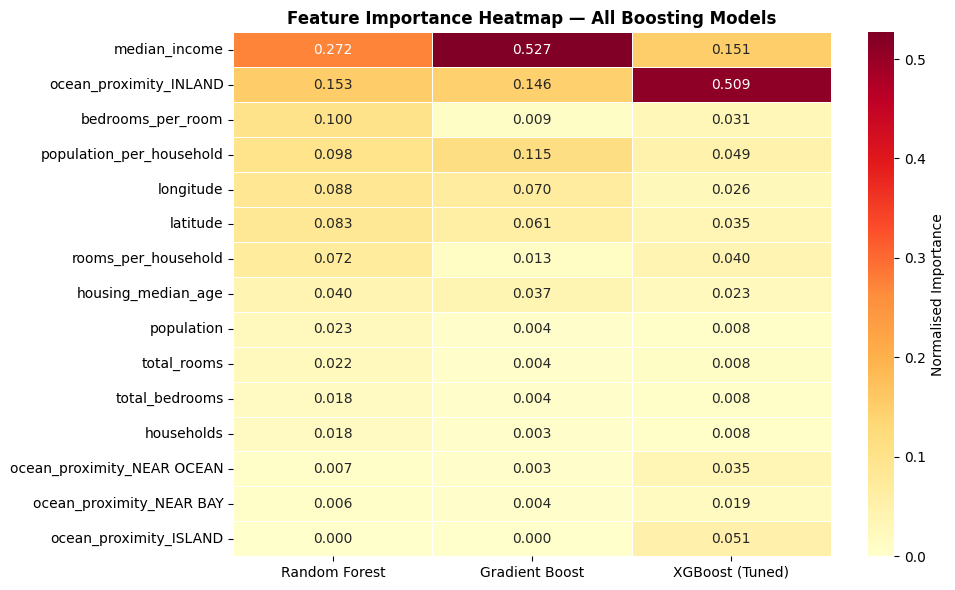


Top 3 features per model:
  Random Forest: ['median_income', 'ocean_proximity_INLAND', 'bedrooms_per_room']
  Gradient Boost: ['median_income', 'ocean_proximity_INLAND', 'population_per_household']
  XGBoost (Tuned): ['ocean_proximity_INLAND', 'median_income', 'ocean_proximity_ISLAND']


In [ ]:
# Normalised importance heatmap
imp_df = pd.DataFrame(importances, index=FEATURES)
imp_norm = imp_df.div(imp_df.sum())  # normalise each column to sum to 1

plt.figure(figsize=(10, 6))
sns.heatmap(imp_norm.sort_values('Random Forest', ascending=False),
            annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Normalised Importance'})
plt.title('Feature Importance Heatmap — All Boosting Models', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 3 features per model:')
for col in imp_df.columns:
    top3 = imp_df[col].sort_values(ascending=False).head(3)
    print(f'  {col}: {list(top3.index)}')

In [ ]:
print('='*65)
print('             KEY TAKEAWAYS')
print('='*65)
print('''
BAGGING
  - Trains N independent models on bootstrap samples → averages
  - Reduces variance, training is parallelisable
  - Works with any base learner

RANDOM FOREST (Bagging + feature randomness)
  - Extra diversity by selecting random features at each split
  - Lower correlation between trees → bigger variance reduction
  - Reliable out-of-the-box, rarely overfits

ADABOOST
  - Sequential: each round up-weights misclassified samples
  - Reduces BIAS — good when base learners are weak (stumps)
  - Sensitive to outliers and noisy data

GRADIENT BOOSTING
  - Sequential: each tree fits residuals of previous ensemble
  - More flexible loss functions than AdaBoost
  - Subsample (stochastic GBM) adds regularisation
  - Cannot parallelise tree building

XGBOOST
  - Gradient Boosting + L1/L2 regularisation + 2nd-order gradients
  - Parallelised column/row subsampling
  - Handles missing values natively
  - Fastest and most regularised — dominates competitions
''')
print('='*65)
best = res_df['Test R²'].idxmax()
print(f'Winner on this dataset: {best} (Test R²={res_df.loc[best,"Test R²"]:.4f}, RMSE=${res_df.loc[best,"RMSE ($)"]:.0f})')

             KEY TAKEAWAYS

BAGGING
  - Trains N independent models on bootstrap samples → averages
  - Reduces variance, training is parallelisable
  - Works with any base learner

RANDOM FOREST (Bagging + feature randomness)
  - Extra diversity by selecting random features at each split
  - Lower correlation between trees → bigger variance reduction
  - Reliable out-of-the-box, rarely overfits

ADABOOST
  - Sequential: each round up-weights misclassified samples
  - Reduces BIAS — good when base learners are weak (stumps)
  - Sensitive to outliers and noisy data

GRADIENT BOOSTING
  - Sequential: each tree fits residuals of previous ensemble
  - More flexible loss functions than AdaBoost
  - Subsample (stochastic GBM) adds regularisation
  - Cannot parallelise tree building

XGBOOST
  - Gradient Boosting + L1/L2 regularisation + 2nd-order gradients
  - Parallelised column/row subsampling
  - Handles missing values natively
  - Fastest and most regularised — dominates competitions

Wi